# Constellation Flat Projection (Portrait A4)

This notebook generates a flat projection of constellations with:
- **Northern skies** on the top half
- **Southern skies** on the bottom half
- Portrait A4 page format (14.5 x 19 cm)
- Constellation stick figures and borders
- Star data from Hipparcos catalog

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from starccato_flow.plotting.sky import plot_galactic_supernovae_polar_hemispheres

MPS device found


## Configuration: Flat All-Sky Projection

Create a complete flat projection with northern skies on top and southern on bottom:

In [2]:
# Flat all-sky projection configuration
OUTPUT_PATH = "../../poster-presentation/crab_supernova_sky_plot.svg"

# Portrait A4 page: 14.5 cm × 19 cm
PAGE_WIDTH_CM = 14.5
PAGE_HEIGHT_CM = 26.0
PAGE_DPI = 300

PLOT_CONFIG = {
    "background": "black",
    "font_family": "sans-serif",
    "font_name": "Futura",
}

In [3]:
import sys
sys.path.insert(0, '/Users/tarineccleston/Desktop/starccato/starccato-flow/src')

from starccato_flow.plotting.load_constellations import load_custom_constellations

# Load custom constellations from file
CUSTOM_CONSTELLATION_FILE = "../../data/sky_map/constellations_custom.txt"
custom_constellations = load_custom_constellations(CUSTOM_CONSTELLATION_FILE)

print(f"✓ Loaded {len(custom_constellations)} custom constellations:")
for name in custom_constellations.keys():
    print(f"  - {name}")

✓ Loaded 18 custom constellations:
  - NZ Long-tailed Bat
  - Swan
  - GibBody
  - GibLA
  - GibRA
  - GibLL
  - GibRL
  - Earthquake Crack
  - Mac1
  - Mac2
  - Mac3
  - Mac4
  - Mac5
  - Mac6
  - Mac7
  - Mac8
  - Mac9
  - Mac10


## Generate Flat All-Sky Projection

Create the complete flat projection with constellations and stars:

630763148.816
✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv
Using landscape orientation: 26.0 cm × 14.5 cm
Using transparent background with text color: white
Using all 1934076 supernovae for contour (no distance data)
✓ Plotted galactic supernovae contours with 4 levels
Loaded 118218 stars from Hipparcos catalog
DEBUG: Selected 5044 stars with mag <= 6.0
DEBUG: Magnitude range: -1.44 to 6.00
DEBUG: RA range: nan to nan
DEBUG: Dec range: nan to nan
DEBUG: NaN count in RA: 3
DEBUG: NaN count in Dec: 3
DEBUG: Sample star: RA=0.27, Dec=-48.81, mag=5.71
DEBUG: Star sizes range: 0.24 to 10.00
DEBUG: Star alphas range: 0.70 to 1.00
✓ Plotted 5044 stars with mag <= 6.0 sized by magnitude, alpha 0.70-1.00
Loaded 18 custom constellations
✓ Plotted 87 constellation stick figure segments (custom)
⊘ Custom constellation boundaries not available (no border file)
✓ Crab Nebula (M1) marked at RA=83.

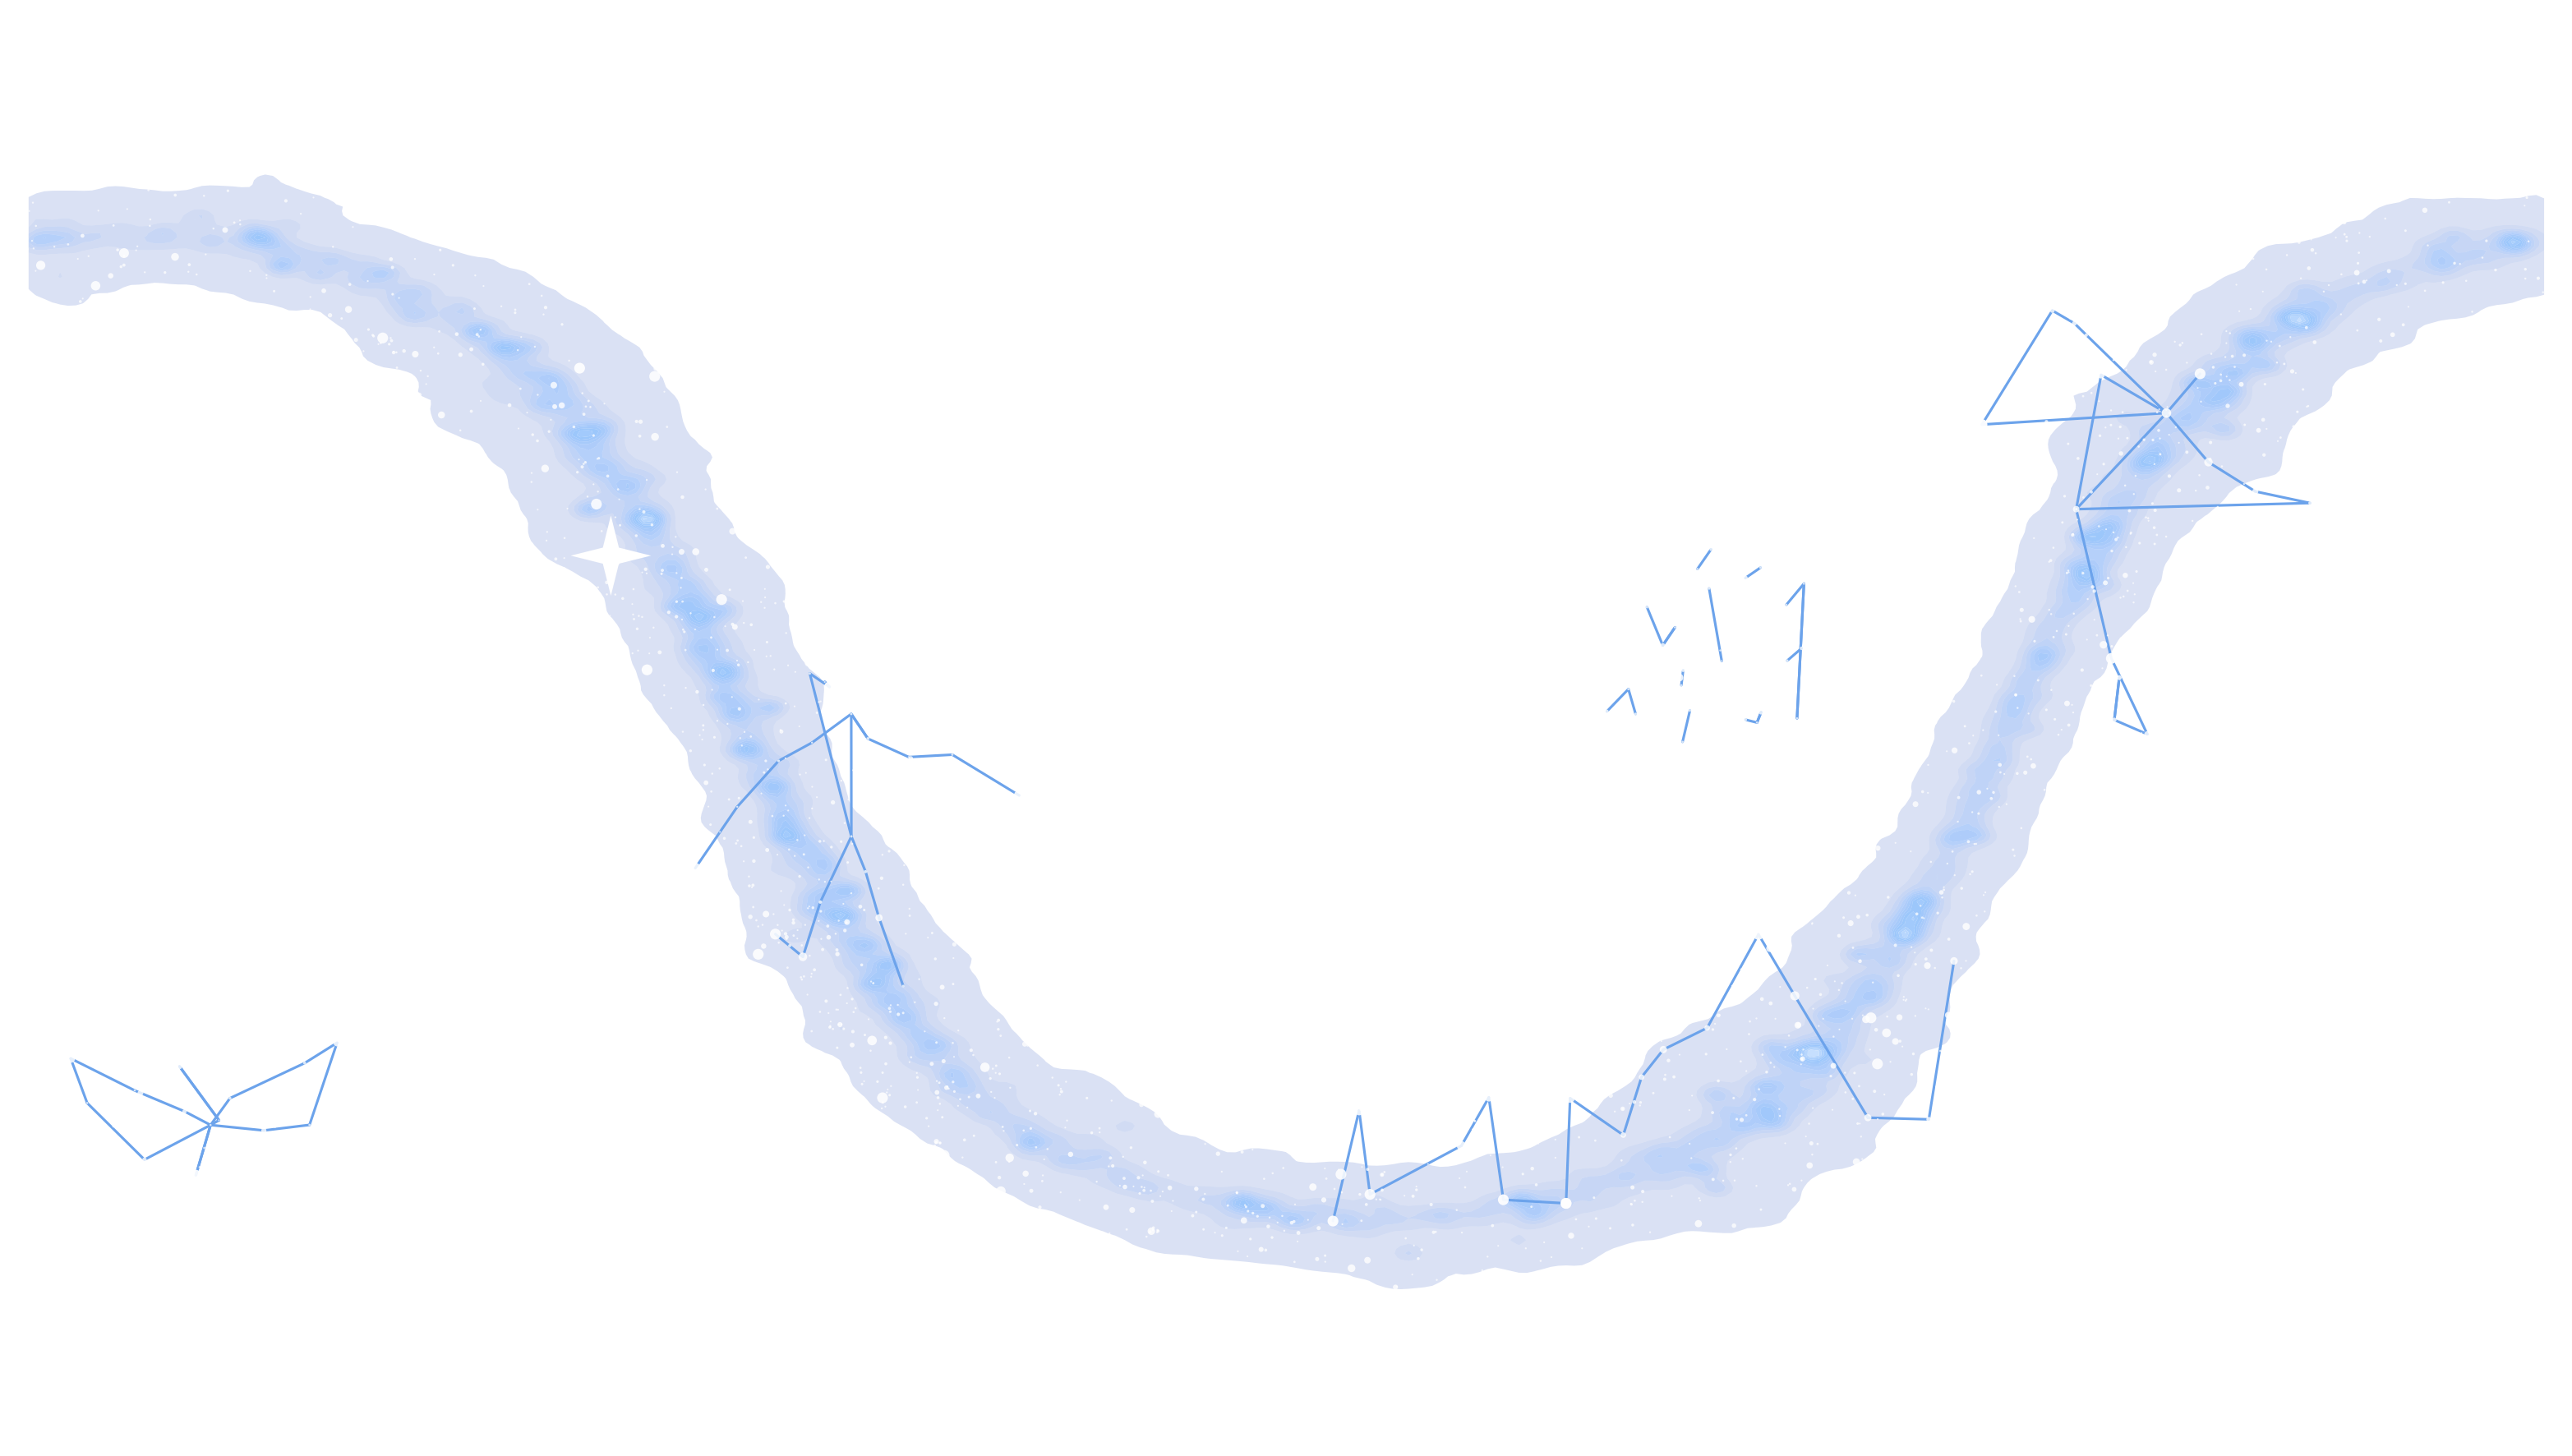

In [4]:
from starccato_flow.plotting.sky_flat import plot_flat_constellation_projection
import importlib
import starccato_flow.plotting.sky_flat
importlib.reload(starccato_flow.plotting.sky_flat)
from starccato_flow.plotting.sky_flat import plot_flat_constellation_projection

from starccato_flow.supernovae.supernovae import Supernovae
ccsn = Supernovae(complex=True)

# Generate the flat all-sky projection with custom constellations
fig, ax = plot_flat_constellation_projection(
    output_path=OUTPUT_PATH,
    supernovae=ccsn,
    page_width_cm=PAGE_WIDTH_CM,
    page_height_cm=PAGE_HEIGHT_CM,
    page_dpi=PAGE_DPI,
    background=PLOT_CONFIG["background"],
    font_family=PLOT_CONFIG["font_family"],
    font_name=PLOT_CONFIG["font_name"],
    mag_limit=6.0,
    plot_stars=True,
    plot_text=False,
    orientation="landscape",
    transparent=True,
    constellation_style="custom",
    custom_constellations=custom_constellations
)

# Quick test: verify data is in axes
print(f"Number of collections in axes: {len(ax.collections)}")
print(f"Number of lines in axes: {len(ax.lines)}")
if len(ax.collections) > 0:
    print(f"First collection offsets shape: {ax.collections[0].get_offsets().shape}")

In [5]:
# Diagnostic: Check where each constellation actually is
from starccato_flow.plotting.sky import _hip_lookup_table_with_mag
hip_lookup = _hip_lookup_table_with_mag()

print("\nConstellation positions (star HIP IDs and their coordinates):")
print("="*70)

for const_name, hip_list in custom_constellations.items():
    print(f"\n{const_name}:")
    
    # hip_list is a flat list of HIP IDs
    # Get coordinates for each star
    for hip in hip_list[:5]:  # Show first 5 stars
        if hip in hip_lookup:
            ra, dec, mag = hip_lookup[hip]
            print(f"  HIP {hip:5d}: RA={ra:7.2f}°, Dec={dec:7.2f}°, mag={mag:5.2f}")
    
    # Get overall bounds
    all_ras = [hip_lookup[hip][0] for hip in hip_list if hip in hip_lookup]
    all_decs = [hip_lookup[hip][1] for hip in hip_list if hip in hip_lookup]
    
    if all_ras and all_decs:
        print(f"  Range: RA {min(all_ras):.1f}°-{max(all_ras):.1f}°, Dec {min(all_decs):.1f}°-{max(all_decs):.1f}°")



Constellation positions (star HIP IDs and their coordinates):

NZ Long-tailed Bat:
  HIP  8240: RA=  26.52°, Dec= -50.82°, mag= 5.49
  HIP  7083: RA=  22.81°, Dec= -49.07°, mag= 3.93
  HIP  4890: RA=  15.70°, Dec= -46.40°, mag= 5.39
  HIP  2081: RA=   6.57°, Dec= -42.31°, mag= 2.40
  HIP  2802: RA=   8.92°, Dec= -48.00°, mag= 5.51
  Range: RA 6.6°-44.6°, Dec -57.2°--40.3°

Swan:
  HIP 102098: RA= 310.36°, Dec=  45.28°, mag= 1.25
  HIP 100453: RA= 305.56°, Dec=  40.26°, mag= 2.23
  HIP 97165: RA= 296.24°, Dec=  45.13°, mag= 2.86
  HIP 95947: RA= 292.68°, Dec=  27.96°, mag= 3.05
  HIP 100453: RA= 305.56°, Dec=  40.26°, mag= 2.23
  Range: RA 279.2°-326.0°, Dec -0.8°-53.4°

GibBody:
  HIP 36388: RA= 112.33°, Dec=  -1.91°, mag= 5.60
  HIP 38373: RA= 117.92°, Dec=   1.77°, mag= 5.12
  HIP 39211: RA= 120.31°, Dec=  -1.39°, mag= 4.69
  HIP 38373: RA= 117.92°, Dec=   1.77°, mag= 5.12
  HIP 38382: RA= 117.94°, Dec= -13.90°, mag= 5.16
  Range: RA 112.0°-120.3°, Dec -13.9°-6.9°

GibLA:
  HIP 3638

In [6]:
# Test kernel
import numpy as np
print("✓ Kernel responsive")

✓ Kernel responsive


## About This Projection

This notebook creates a **flat all-sky projection** using an equirectangular (plate-carrée) projection:
- **X-axis**: Right Ascension (RA) from 0° to 360°
- **Y-axis**: Declination (Dec) from -90° to +90°
- **Top half**: Northern celestial hemisphere (Dec > 0)
- **Bottom half**: Southern celestial hemisphere (Dec < 0)

The visualization shows:
- **Constellation stick figures**: Lines connecting bright stars in each constellation
- **Constellation borders**: IAU constellation boundaries

The equirectangular projection is linear and perfect for:
- Printing on portrait A4 pages
- Showing the complete celestial sphere with proper scale
- Displaying all 88 IAU constellations

In [7]:
# Verify the file was created
import os
if os.path.exists(OUTPUT_PATH):
    file_size_mb = os.path.getsize(OUTPUT_PATH) / (1024**2)
    print(f"✓ File created successfully: {OUTPUT_PATH}")
    print(f"✓ File size: {file_size_mb:.2f} MB")
    print(f"✓ Page dimensions: {PAGE_WIDTH_CM} cm × {PAGE_HEIGHT_CM} cm")
    print(f"✓ Resolution: {PAGE_DPI} DPI")
else:
    print(f"✗ File not found: {OUTPUT_PATH}")

✓ File created successfully: ../../poster-presentation/crab_supernova_sky_plot.svg
✓ File size: 3.59 MB
✓ Page dimensions: 14.5 cm × 26.0 cm
✓ Resolution: 300 DPI
